In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_unit_gaussian_samples(D):
    plt.figure(figsize=(8, 5))
    plt.title(f'Samples from a unit {D}D Gaussian')
    
    # 生成等间距的x值
    xs = np.linspace(0, 1, D)
    
    for _ in range(10):
        # 生成D维高斯分布样本
        ys = np.random.multivariate_normal(np.zeros(D), np.eye(D))
        plt.plot(xs, ys, linewidth=1)
    
    # 返回图形对象
    return plt.gcf()



# 调用函数并显示图形
plot_unit_gaussian_samples(20)
plt.show()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/zhanghaoran/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_29336/1816195143.py", line 3, in <module>
    from bayes_opt import BayesianOptimization
  File "/home/zhanghaoran/anaconda3/envs/pydm_env/lib/python3.10/site-packages/bayes_opt/__init__.py", line 2, in <module>
    from .bayesian_optimization import BayesianOptimization, Events
  File "/home/zhanghaoran/anaconda3/envs/pydm_env/lib/python3.10/site-packages/bayes_opt/bayesian_optimization.py", line 12, in <module>
    from .logger import _get_default_logger
  File "/home/zhanghaoran/anaconda3/envs/pydm_env/lib/python3.10/site-packages/bayes_opt/logger.py", line 8, in <module>
    from colorama import Fore, just_fix_windows_console
ImportError: cannot import name 'just_fix_windows_console' from 'colorama' (/usr/lib/python3/dist-packages/colorama/__init__.py)



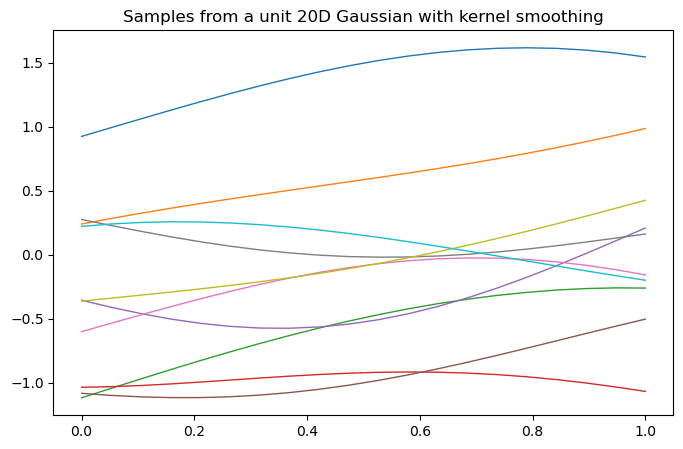

In [2]:
def kernel_func(xs, ys, sigma=1, l=1):
    """Sqared Exponential kernel as above but designed to return the whole
    covariance matrix - i.e. the pairwise covariance of the vectors xs & ys.
    Also with two parameters which are discussed at the end.
    """
    # Pairwise difference matrix.
    dx = np.expand_dims(xs, 1) - np.expand_dims(ys, 0)
    return (sigma ** 2) * np.exp(-((dx / l) ** 2) / 2)

def mean_func(x):
    """The mean function. As discussed, we can let the mean always be zero."""
    return np.zeros_like(x)


def plot_kernel_gaussian_samples(D):
    plt.figure(figsize=(8, 5))
    plt.title(f'Samples from a unit {D}D Gaussian with kernel smoothing')
    
    # 生成等间距的x值
    xs = np.linspace(0, 1, D)
    
    for _ in range(10):
        # 生成D维带平滑高斯分布样本
        ys = np.random.multivariate_normal(mean_func(xs), kernel_func(xs, xs))
        plt.plot(xs, ys, linewidth=1)
    
    # 返回图形对象
    return plt.gcf()



# 调用函数并显示图形
plot_kernel_gaussian_samples(20)
plt.show()

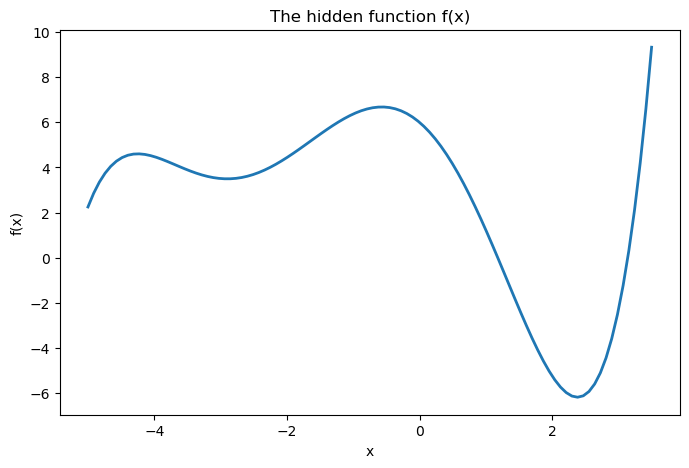

In [3]:
def f(x):
    coefs = [6, -2.5, -2.4, -0.1, 0.2, 0.03]
    total = 0
    for exp, coef in enumerate(coefs):
        total += coef * (x ** exp)
    return total

xs = np.linspace(-5.0, 3.5, 100)
ys = f(xs)

plt.figure(figsize=(8, 5))
plt.title(f'The hidden function f(x)')
plt.plot(xs, ys, linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

In [4]:
x_obs = np.array([-4, -1.5, 0, 1.5, 2.5, 2.7])
y_obs = f(x_obs)

x_s = np.linspace(-8, 7, 80)



In [5]:
K = kernel_func(x_obs, x_obs)
K_s = kernel_func(x_obs, x_s)
K_ss = kernel_func(x_s, x_s)


K_sTKinv = np.matmul(K_s.T, np.linalg.pinv(K))

mu_s = mean_func(x_s) + np.matmul(K_sTKinv, y_obs - mean_func(x_obs))
Sigma_s = K_ss - np.matmul(K_sTKinv, K_s)

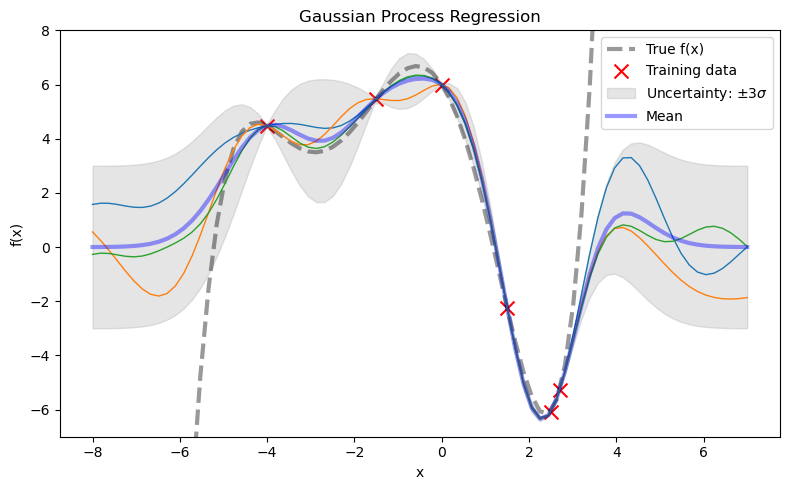

In [6]:


plt.figure(figsize=(8, 5))
plt.title("Gaussian Process Regression")
plt.ylim(-7, 8)


# 1. 绘制真实函数（黑色虚线）
y_true = f(x_s)
plt.plot(x_s, y_true, 'k--', linewidth=3, alpha=0.4, label='True f(x)')

# 2. 绘制观测数据点（十字标记）
plt.scatter(x_obs, y_obs, s=100, marker='x', c='red', label='Training data')

# 3. 绘制不确定性区域（灰色半透明区域）
stds = np.sqrt(Sigma_s.diagonal())
plt.fill_between(x_s, mu_s - 3*stds, mu_s + 3*stds, 
                 color='gray', alpha=0.2, label='Uncertainty: ±3' + r"$\sigma$")

for _ in range(3):
   y_s = np.random.multivariate_normal(mu_s, Sigma_s)
   plt.plot(x_s, y_s, linewidth=1)

plt.plot(x_s, mu_s, 'b-', linewidth=3, alpha=0.4, label='Mean')


plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('f(x)')
# plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
